In [50]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_reward_grids, plot_most_common_choice_trajectory, animate_heatmap_trajectory

sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

## 1. Asocial individuals, human-like parameters

In [75]:
rng = np.random.default_rng(42)

grid_size = 20
reward_params = {
    'frequency': 2.5,
    'center': (grid_size // 4, grid_size // 4),
    'correlation': 1
}
params = {
    "n": [30],
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": grid_size * 1.5 / (2*np.pi * reward_params['frequency']),
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=80,
    display_progress=True,
    data_collection_period=1,
    number_processes=None
)

  0%|          | 0/1 [00:00<?, ?it/s]

### A. Plot mean across many iterations

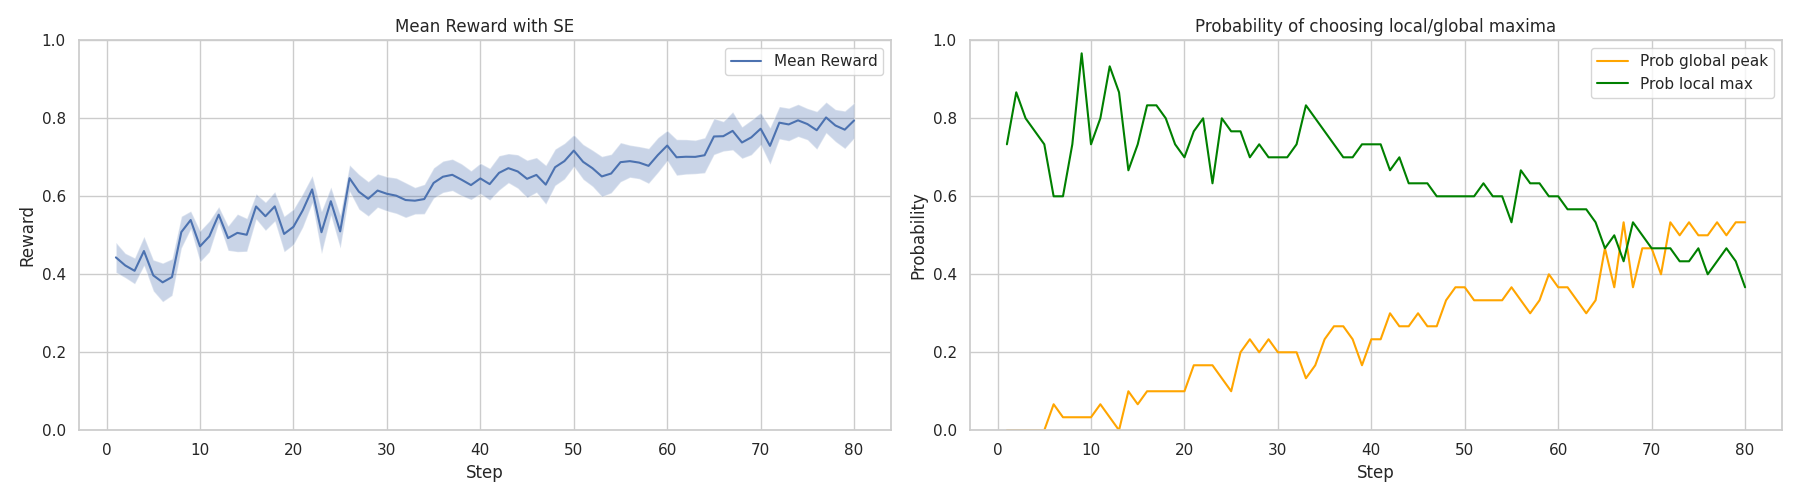

In [76]:
df_batch = pd.DataFrame(batch_results)

# Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['mean_reward'], label='Mean Reward')
axes[0].fill_between(df_batch['Step'], df_batch['mean_reward'] - df_batch['se_reward'], df_batch['mean_reward'] + df_batch['se_reward'], alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['prob_near_peak'], label='Prob global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['prob_local_max'], label='Prob local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

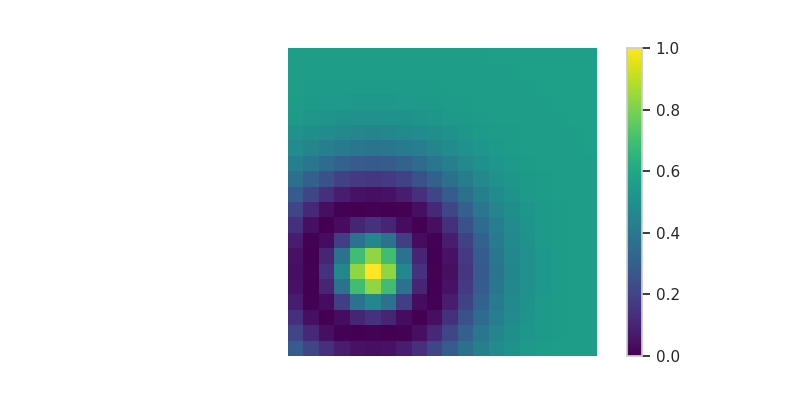

In [74]:
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_reward_grid(reward)

### B. Plot Individual trajectories

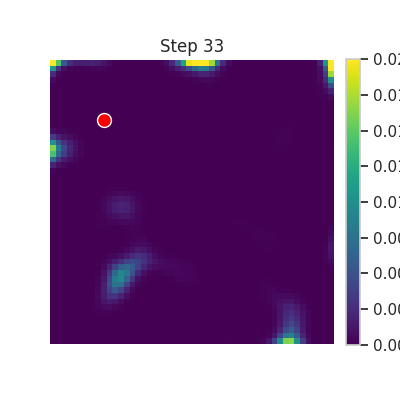

In [8]:
df_batch = pd.DataFrame(batch_results)

heatmaps = df_batch['policy'].to_numpy()  # shape (60,), each element is a 2D array
fig, ax = plt.subplots(figsize=(4, 4))

vmin = min(h.min() for h in heatmaps)
vmax = min(max(h.max() for h in heatmaps), 0.02)

im = ax.imshow(
    heatmaps[1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
)
ax.scatter(df_batch.loc[0, 'choice'][0], df_batch.loc[0, 'choice'][1], color='red', s=100, edgecolor='white')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def update(frame):
    ax.clear()  # Clear previous scatter points
    # im.set_array(heatmaps[frame+1])  # Update the data
    im = ax.imshow(
        heatmaps[frame+1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
    )
    ax.scatter(df_batch.loc[frame, 'choice'][0], df_batch.loc[frame, 'choice'][1], color='red', s=100, edgecolor='white')
    ax.set_title(f'Step {frame}')
    ax.axis('off')
    return im,

ani = FuncAnimation(fig, update, frames=len(heatmaps)-1, repeat=False)
ani.save('policy_evolution.gif', writer='pillow', fps=1)

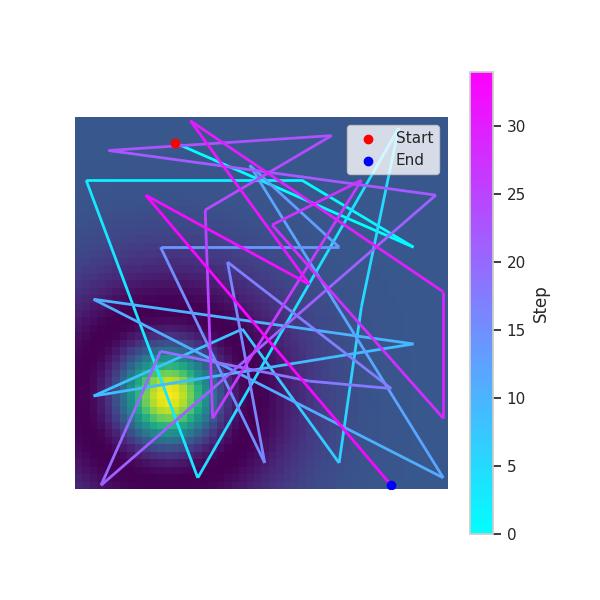

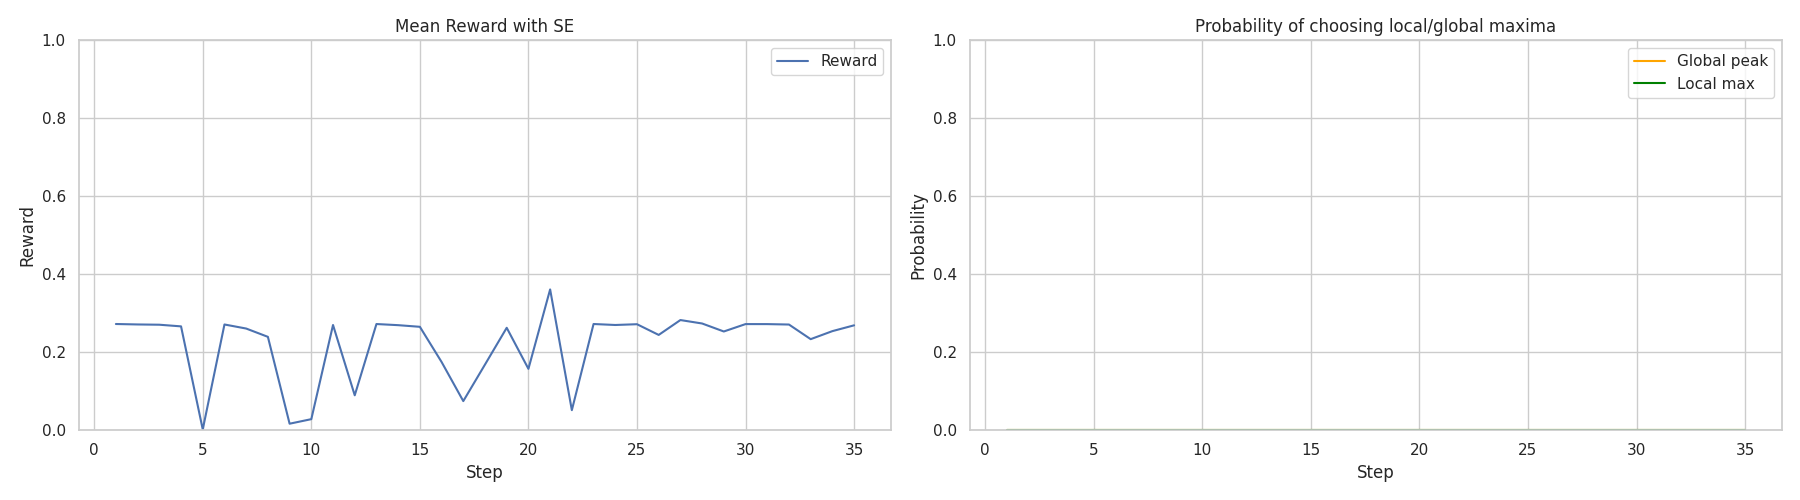

In [9]:
# 1. Plot most common choice trajectory
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_most_common_choice_trajectory(df_batch, reward, title='', choice_col='choice')

# 2. Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['reward'], label='Reward')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['near_peak'], label='Global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['local_max'], label='Local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Test Correlated DoG

### 2.a Simulate average behavior

In [71]:
grid_size   = 33
lambda_true = 4.5
# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9
}

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true/2.0,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true/2.0,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "model_reporters_to_collect": ['mean_cumulative_reward'],
        "agent_reporters_to_collect": ['reward', 'global_max', 'local_max', 'no_max']
    }
}

In [72]:
n_runs      = 100
max_steps   = 30

batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[None]*n_runs,
    parameters=params['lambda_is_sigma_i_low_random'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/400 [00:00<?, ?it/s]

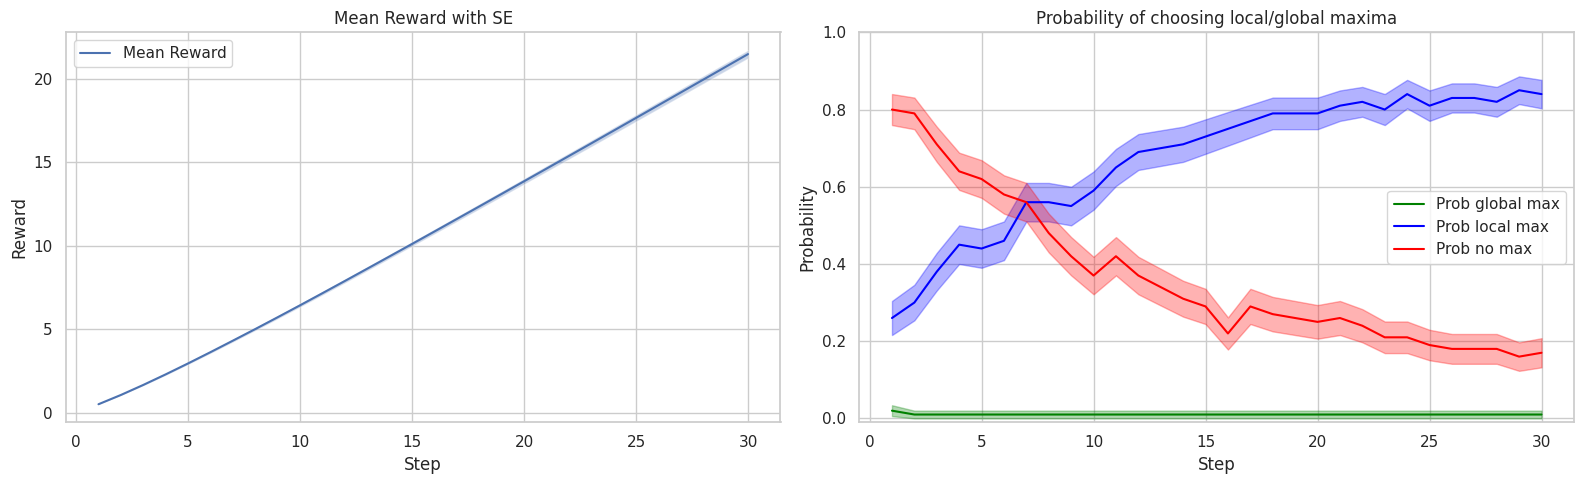

In [ ]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
    }).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.01, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.b Analyze sample individual

In [15]:
seed = 24
rng  = np.random.default_rng(seed)

grid_size   = 33
lambda_true = 4.5
n_runs      = 1
max_steps   = 30
# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9
}

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_inner_naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    }
}

In [16]:
batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[rng]*n_runs,
    parameters=params['lambda_inner_naito'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

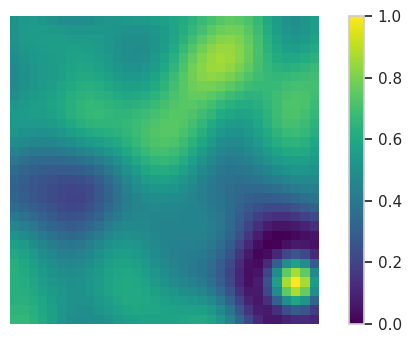

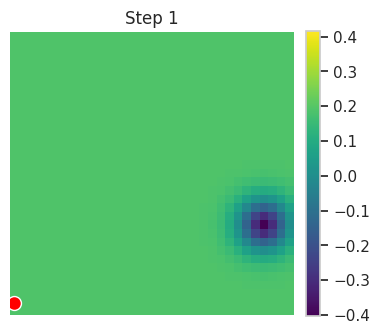

In [17]:
rng = np.random.default_rng(seed)
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
    'n_children': 1
}

_, reward, _ = make_parent_and_children_correlated_dog(
    rng=rng,
    grid_size=grid_size,
    **reward_params
)
plot_reward_grid(reward[0])
plt.show()

df_batch = pd.DataFrame(batch_results)
ani, fig, ax = animate_heatmap_trajectory(
    df_batch,
    heatmap_col='value',
    choice_col='choice',
    save_path='policy_evolution.gif',
    fps=3,
    start_idx=1,
    repeat=False,
    title_prefix='Step',
)

## 3. Sweep $\beta$ and $\tau$ parameters

In [ ]:
grid_size = 33
lambda_true = 4.5
n_runs = 100
max_steps = 30
summary_window = 5

# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated DoG environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
}

params = {
    "n": 1,
    "grid_size": grid_size,
    "beta": np.arange(0, 0.51, 0.025),
    "length_scale": lambda_true * np.array([0.5, 1.0, naito_lambda_ratio, 2.0]),
    "tau": np.array([0.005]) + np.arange(0.01, 0.11, 0.01),
    "alpha": 0,
    "reward_env_type": 'corr_dog',
    "reward_env_params": [reward_params],
    "summary_window": summary_window,
    "collect_agent_reporters": False,
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=-1,
    number_processes=None,
    rng=[None] * n_runs,
 )

  0%|          | 0/84000 [00:00<?, ?it/s]

In [ ]:
# df_batch = pd.DataFrame(batch_results)
# df_batch.to_csv('parameter_sweep_corr_dog.csv', index=False)

df_batch = pd.DataFrame(batch_results)

required_columns = [
    'beta',
    'length_scale',
    'tau',
    'mean_reward_last_window',
    'cumulative_reward',
    'global_max_last_choice',
]
missing_columns = [column for column in required_columns if column not in df_batch.columns]
if missing_columns:
    raise KeyError(f"Missing columns in batch results: {missing_columns}")

df_batch[required_columns].head()

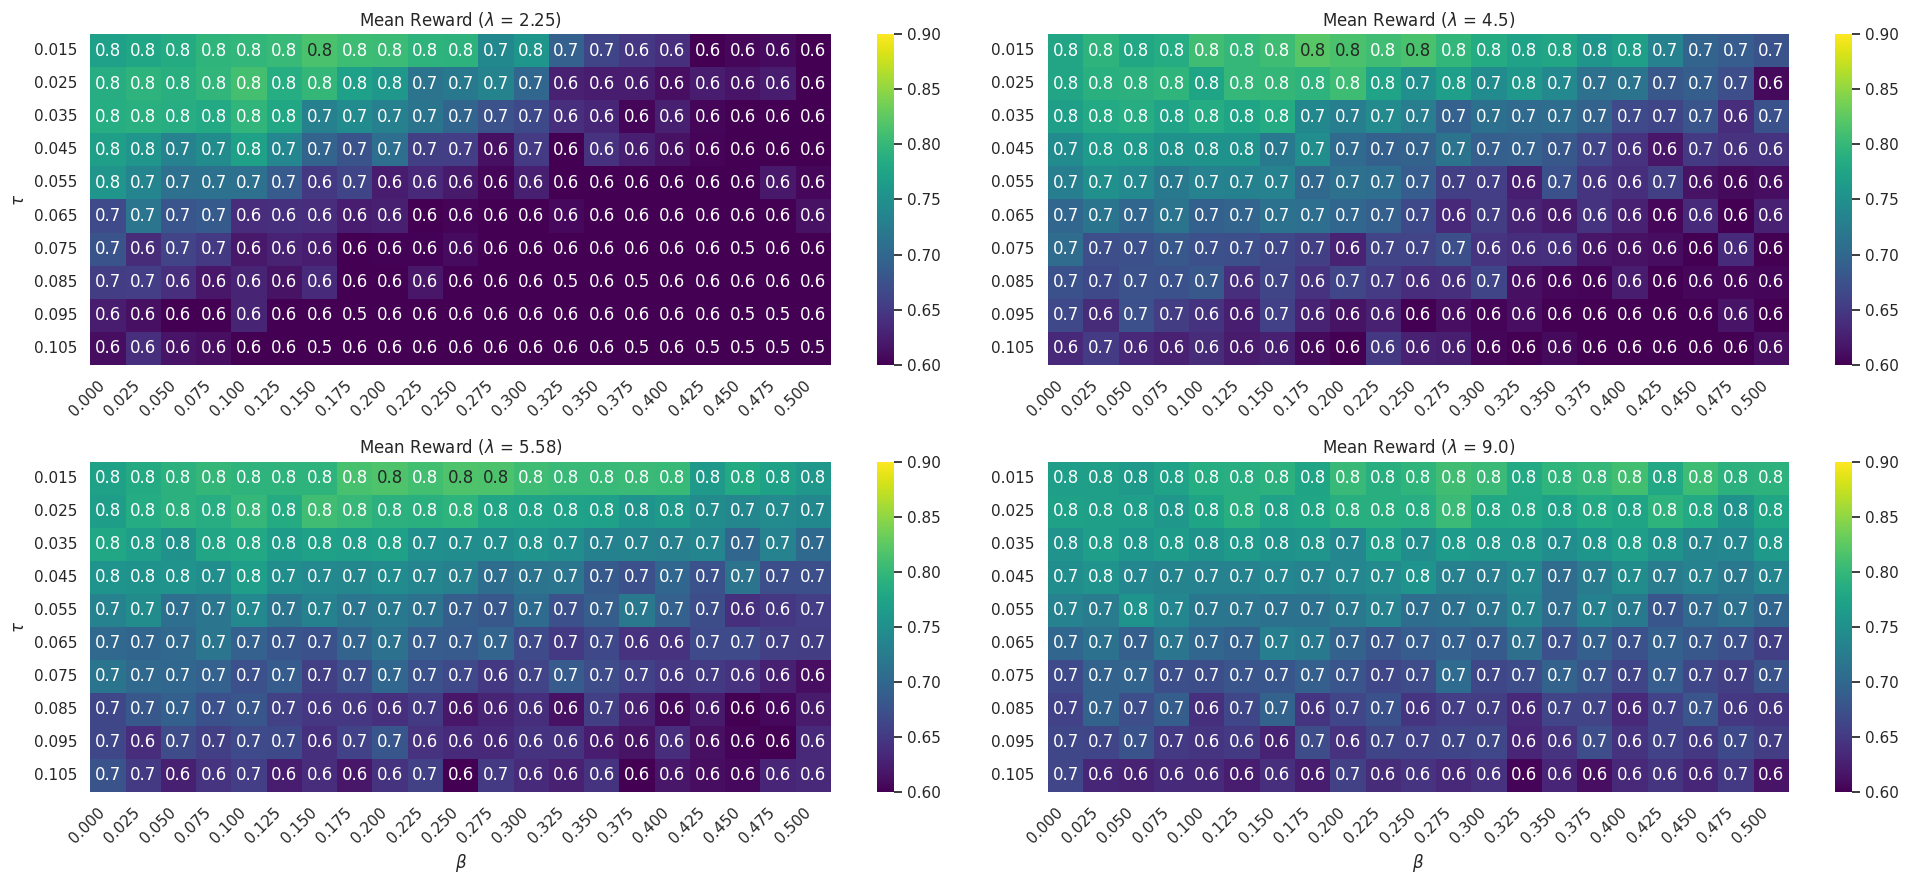

In [ ]:
def summarize_batch_metrics(df, metric_columns, group_columns=('beta', 'length_scale', 'tau')):
    """Aggregate batch results into one value per (beta, length_scale, tau)."""
    aggregation = {metric: 'mean' for metric in metric_columns}
    return df.groupby(list(group_columns), as_index=False).agg(aggregation)


def plot_metric_heatmaps_by_lambda(
    summary_df,
    metric_column,
    metric_label,
    fmt='.2f',
    cmap='viridis',
    ncols=2,
    vmin=None,
    vmax=None,
    cbar_label=None,
 ):
    """Plot one heatmap per lambda panel for a given metric."""
    lambda_values = np.sort(summary_df['length_scale'].unique())
    n_panels = len(lambda_values)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(9.5 * ncols, 4.5 * nrows), squeeze=False
    )
    axes_flat = axes.ravel()

    for panel_idx, lambda_value in enumerate(lambda_values):
        ax = axes_flat[panel_idx]
        row_idx = panel_idx // ncols
        col_idx = panel_idx % ncols

        df_lambda = summary_df[summary_df['length_scale'] == lambda_value]
        pivot_table = df_lambda.pivot(index='tau', columns='beta', values=metric_column)

        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=True,
            ax=ax,
            cbar_kws={'label': cbar_label if cbar_label is not None else metric_label},
        )

        ax.set_title(rf"{metric_label} ($\\lambda$ = {float(lambda_value):.3f})")
        ax.set_xticklabels(
            [f"{float(beta):.3f}" for beta in pivot_table.columns],
            rotation=45,
            ha='right',
        )
        ax.set_yticklabels(
            [f"{float(tau):.3f}" for tau in pivot_table.index],
            rotation=0,
        )

        show_x = row_idx == (nrows - 1)
        show_y = col_idx == 0
        ax.set_xlabel(r'$\\beta$' if show_x else '')
        ax.set_ylabel(r'$\\tau$' if show_y else '')

    for panel_idx in range(n_panels, len(axes_flat)):
        axes_flat[panel_idx].set_visible(False)

    plt.tight_layout()
    plt.show()


metric_specs = [
    {
        'column': 'mean_reward_last_window',
        'label': f'Mean Reward (Last {summary_window} Steps)',
        'fmt': '.2f',
        'vmin': 0.0,
        'vmax': 1.0,
    },
    {
        'column': 'cumulative_reward',
        'label': 'Cumulative Reward',
        'fmt': '.1f',
        'vmin': None,
        'vmax': None,
    },
    {
        'column': 'global_max_last_choice',
        'label': 'P(Global Max at Final Choice)',
        'fmt': '.2f',
        'vmin': 0.0,
        'vmax': 1.0,
    },
]

summary_df = summarize_batch_metrics(
    df_batch,
    metric_columns=[spec['column'] for spec in metric_specs],
    group_columns=('beta', 'length_scale', 'tau'),
)

for spec in metric_specs:
    plot_metric_heatmaps_by_lambda(
        summary_df=summary_df,
        metric_column=spec['column'],
        metric_label=spec['label'],
        fmt=spec['fmt'],
        cmap='viridis',
        ncols=2,
        vmin=spec['vmin'],
        vmax=spec['vmax'],
    )